In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


# IMP Scratch

Exploratory cells for the IMP dataset: file structure checks, image/mask pairing, plotting, and split-wide statistics.


## Look at IMP dataset

In [2]:
imp_path = Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/")
items = list(imp_path.glob("*"))
items

[PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/test'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/val'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/.DS_Store'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/test.txt'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train.txt'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train_0_001.txt'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train_0_005.txt'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train_0_005_ot.txt'),
 PosixPath('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/

In [25]:
train_dir = Path('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train')
val_dir = Path('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/val')
test_dir = Path('/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/test')

In [29]:
train_files = [elem for elem in train_dir.glob("*") if ".DS_Store" not in str(elem)]
val_files = [elem for elem in val_dir.glob("*") if ".DS_Store" not in str(elem)]
test_files = [elem for elem in test_dir.glob("*") if ".DS_Store" not in str(elem)]

train_tifs = [f for f in train_files if str(f).endswith(".tif")]
val_tifs = [f for f in val_files if str(f).endswith(".tif")]
test_tifs = [f for f in test_files if str(f).endswith(".tif")]

print(f"Total train files: {len(train_files)}, num tifs: {len(train_tifs)}")
print(f"Total val files: {len(val_files)}, num tifs: {len(val_tifs)}")
print(f"Total test files: {len(test_files)}, num tifs: {len(test_tifs)}")

Total train files: 21126, num tifs: 21126
Total val files: 4044, num tifs: 4041
Total test files: 2832, num tifs: 2832


In [22]:
for split_files in [train_tifs, val_tifs, test_tifs]:
    negative_files = [f for f in split_files if "negative" in str(f)]
    target_files = [f for f in split_files if "target" in str(f)]
    print(f"Found {len(negative_files)} negatives, {len(target_files)} targets")
    for file in negative_files[:100]:
        train_ds = xr.open_dataset(file)
        if int(train_ds.sizes['band']) != 1: print(">1 band found in negative files")
    for file in target_files[:100]:
        train_ds = xr.open_dataset(file)
        if int(train_ds.sizes['band']) != 1: print(">1 band found in target files")

Found 14094 negatives, 7032 targets
Found 2571 negatives, 1470 targets
Found 2001 negatives, 831 targets


In [21]:
print(len(train_tifs))
print(len(val_tifs))
print(len(test_tifs))

21126
4041
2832


## Agent code

### Snippet 1

In [30]:
from pathlib import Path
from collections import Counter, defaultdict
import re

root = Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset")

for split in ["train", "val", "test"]:
  split_dir = root / split
  files = [p for p in split_dir.iterdir() if p.name != ".DS_Store"]

  exts = Counter(p.suffix.lower() for p in files)
  labels = Counter(
      "target" if "__target_" in p.name else
      "negative" if "__negative_" in p.name else
      "unknown"
      for p in files
  )

  print(f"\n{split}")
  print("num files:", len(files))
  print("extensions:", exts)
  print("label/name patterns:", labels)
  print("examples:")
  for p in files[:5]:
      print(" ", p.name)


train
num files: 21126
extensions: Counter({'.tif': 21126})
label/name patterns: Counter({'negative': 14094, 'target': 7032})
examples:
  M102414599RE.ech.cog__negative_00006__c1394_r31356_img.tif
  M102414599RE.ech.cog__negative_00006__c1394_r31356_mask.tif
  M102414599RE.ech.cog__negative_00006__c1394_r31356_mask_orig.tif
  M104354874RE.ech.cog__negative_00003__c923_r26236_img.tif
  M104354874RE.ech.cog__negative_00003__c923_r26236_mask.tif

val
num files: 4044
extensions: Counter({'.tif': 4041, '.xml': 3})
label/name patterns: Counter({'negative': 2571, 'target': 1473})
examples:
  M102414599RE.ech.cog__negative_00003__c1991_r71814_img.tif
  M102414599RE.ech.cog__negative_00003__c1991_r71814_mask.tif
  M102414599RE.ech.cog__negative_00003__c1991_r71814_mask_orig.tif
  M108951277RE.ech.cog__negative_00047__c1589_r8567_img.tif
  M108951277RE.ech.cog__negative_00047__c1589_r8567_mask.tif

test
num files: 2832
extensions: Counter({'.tif': 2832})
label/name patterns: Counter({'negative'

### Snippet 2

In [31]:
import rasterio
import numpy as np

sample = next((root / "train").glob("*.tif"))

with rasterio.open(sample) as src:
  print("path:", sample)
  print("count:", src.count)
  print("shape:", src.height, src.width)
  print("dtype:", src.dtypes)
  print("nodata:", src.nodata)
  print("tags:", src.tags())
  arr = src.read()
  print("array shape:", arr.shape)
  print("min/max/mean/std:", np.nanmin(arr), np.nanmax(arr), np.nanmean(arr), np.nanstd(arr))

path: /explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset/train/M102414599RE.ech.cog__negative_00006__c1394_r31356_img.tif
count: 1
shape: 256 256
dtype: ('float32',)
nodata: -3.4028226550889045e+38
tags: {'AREA_OR_POINT': 'Area'}
array shape: (1, 256, 256)
min/max/mean/std: -0.0005304716 0.012841965 0.0009114246 0.0011277042


### Snippet 3

In [32]:
from pathlib import Path
import rasterio
import numpy as np
from collections import Counter

root = Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset")

for split in ["train", "val", "test"]:
  print(f"\n{split}")
  for pattern in ["*negative*_mask.tif", "*target*_mask.tif", "*target*_mask_orig.tif"]:
      vals = Counter()
      files = sorted((root / split).glob(pattern))[:20]
      for p in files:
          with rasterio.open(p) as src:
              arr = src.read(1)
          vals.update(np.unique(arr).tolist())
      print(pattern, vals)


train


/tmp/ipykernel_556907/477597537.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1)


*negative*_mask.tif Counter({0: 20})
*target*_mask.tif Counter({0: 20, 1: 20})
*target*_mask_orig.tif Counter({0: 20, 1: 20})

val
*negative*_mask.tif Counter({0: 20})
*target*_mask.tif Counter({0: 20, 1: 20})
*target*_mask_orig.tif Counter({0: 20, 1: 20})

test
*negative*_mask.tif Counter({0: 20})
*target*_mask.tif Counter({0: 20, 1: 20})
*target*_mask_orig.tif Counter({0: 20, 1: 20})


### Snippet 4

In [33]:
for split in ["train", "val", "test"]:
  split_dir = root / split
  img_stems = {p.name.removesuffix("_img.tif") for p in split_dir.glob("*_img.tif")}
  mask_stems = {p.name.removesuffix("_mask.tif") for p in split_dir.glob("*_mask.tif")}
  orig_stems = {p.name.removesuffix("_mask_orig.tif") for p in split_dir.glob("*_mask_orig.tif")}

  print(f"\n{split}")
  print("img:", len(img_stems), "mask:", len(mask_stems), "mask_orig:", len(orig_stems))
  print("missing masks:", len(img_stems - mask_stems))
  print("missing imgs:", len(mask_stems - img_stems))
  print("missing mask_orig:", len(img_stems - orig_stems))


train
img: 7042 mask: 7042 mask_orig: 7042
missing masks: 0
missing imgs: 0
missing mask_orig: 0

val
img: 1347 mask: 1347 mask_orig: 1347
missing masks: 0
missing imgs: 0
missing mask_orig: 0

test
img: 944 mask: 944 mask_orig: 944
missing masks: 0
missing imgs: 0
missing mask_orig: 0


## Plot IMP Image/Label Samples

/tmp/ipykernel_556907/3533308132.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  image = src.read(1)
/tmp/ipykernel_556907/3533308132.py:37: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  label = src.read(1)


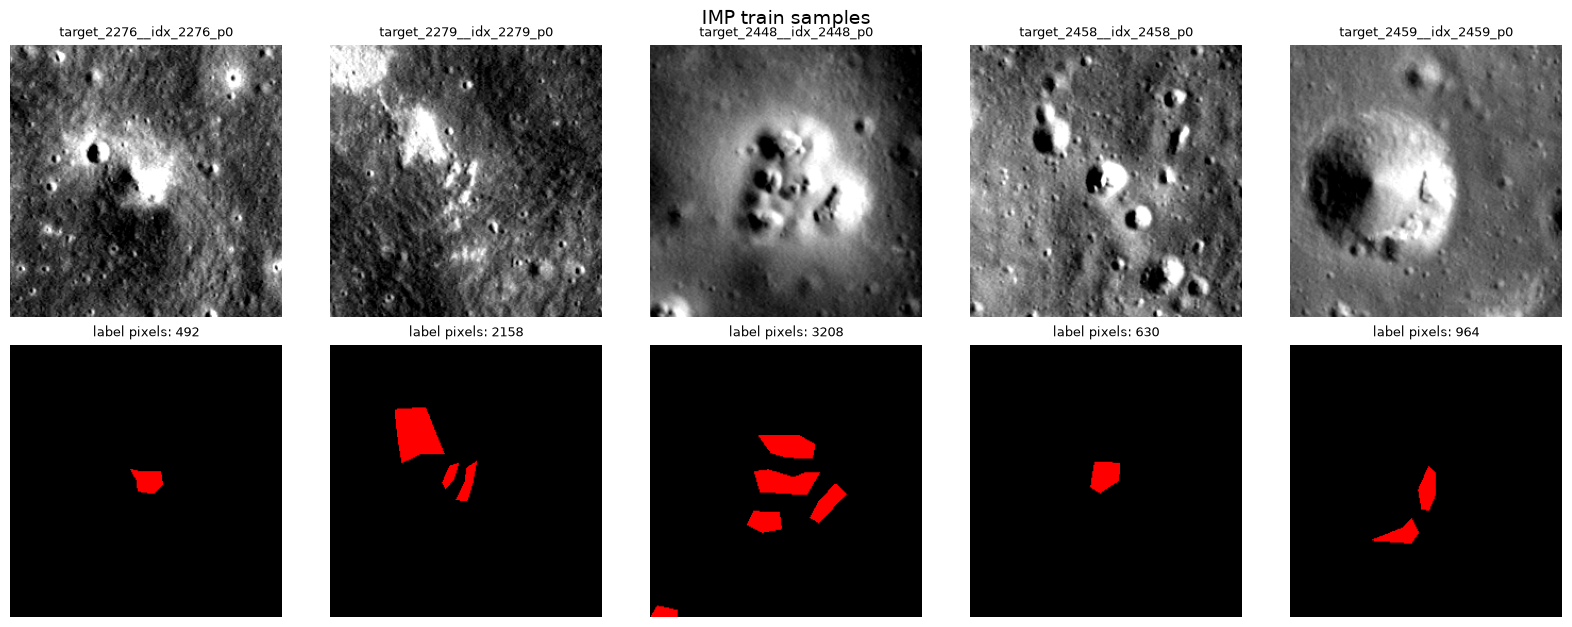

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import ListedColormap

IMP_PLOT_SPLIT = "train"
IMP_PLOT_N_SAMPLES = 5
IMP_PLOT_INCLUDE_NEGATIVES = False
IMP_PLOT_MASK_KIND = "mask"  # "mask" or "mask_orig"

imp_root = root if "root" in globals() else Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset")
imp_split_dir = imp_root / IMP_PLOT_SPLIT

sample_pattern = "*_img.tif" if IMP_PLOT_INCLUDE_NEGATIVES else "*target*_img.tif"
image_paths = sorted(imp_split_dir.glob(sample_pattern))[:IMP_PLOT_N_SAMPLES]
if len(image_paths) < IMP_PLOT_N_SAMPLES:
    raise ValueError(
        f"Found only {len(image_paths)} sample(s) for pattern {sample_pattern!r} "
        f"under {imp_split_dir}."
    )

label_cmap = ListedColormap(["black", "red"])
fig, axes = plt.subplots(2, IMP_PLOT_N_SAMPLES, figsize=(3.2 * IMP_PLOT_N_SAMPLES, 6.0), constrained_layout=True)

for col, image_path in enumerate(image_paths):
    sample_stem = image_path.name.removesuffix("_img.tif")
    label_path = imp_split_dir / f"{sample_stem}_{IMP_PLOT_MASK_KIND}.tif"
    if not label_path.exists():
        raise FileNotFoundError(f"Missing label for {image_path.name}: {label_path}")

    with rasterio.open(image_path) as src:
        image = src.read(1)
        image_nodata = src.nodata
    with rasterio.open(label_path) as src:
        label = src.read(1)

    image = image.astype("float32", copy=False)
    if image_nodata is not None:
        image = np.where(image == image_nodata, np.nan, image)

    lo, hi = np.nanpercentile(image, [2, 98])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = np.nanmin(image), np.nanmax(image)

    title = sample_stem.split(".ech.cog__")[-1]
    axes[0, col].imshow(image, cmap="gray", vmin=lo, vmax=hi)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(label, cmap=label_cmap, vmin=0, vmax=1)
    axes[1, col].set_title(f"label pixels: {int(np.count_nonzero(label))}", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle(f"IMP {IMP_PLOT_SPLIT} samples", fontsize=14, y=1.02)
plt.show()

### Get stats

In [38]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import rasterio
from tqdm.auto import tqdm

IMP_ROOT = Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset")
NAC_PRETRAIN_MEAN = 0.02094413563125313
NAC_PRETRAIN_STD = 0.019197145587676916
NUM_WORKERS = 10

def image_partial_stats(path: Path):
  with rasterio.open(path) as src:
      arr = src.read([1])[0].astype("float64", copy=False)
      nodata = src.nodata

  if nodata is not None:
      arr = arr[arr != nodata]
  arr = arr[np.isfinite(arr)]

  if arr.size == 0:
      return {
          "n": 0,
          "sum": 0.0,
          "sum_sq": 0.0,
          "min": np.inf,
          "max": -np.inf,
      }

  return {
      "n": int(arr.size),
      "sum": float(arr.sum()),
      "sum_sq": float(np.square(arr).sum()),
      "min": float(arr.min()),
      "max": float(arr.max()),
  }

def split_image_stats(split: str):
  image_paths = sorted((IMP_ROOT / split).glob("*_img.tif"))

  n = 0
  total = 0.0
  total_sq = 0.0
  min_val = np.inf
  max_val = -np.inf

  with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
      results = executor.map(image_partial_stats, image_paths, chunksize=32)
      for partial in tqdm(results, total=len(image_paths), desc=f"{split} images"):
          n += partial["n"]
          total += partial["sum"]
          total_sq += partial["sum_sq"]
          min_val = min(min_val, partial["min"])
          max_val = max(max_val, partial["max"])

  mean = total / n
  std = np.sqrt((total_sq / n) - mean**2)

  return {
      "split": split,
      "images": len(image_paths),
      "pixels": n,
      "mean": mean,
      "std": std,
      "min": min_val,
      "max": max_val,
      "mean_delta_vs_pretrain": mean - NAC_PRETRAIN_MEAN,
      "std_ratio_vs_pretrain": std / NAC_PRETRAIN_STD,
  }

stats = [split_image_stats(split) for split in ["train", "val", "test"]]

for row in stats:
  print(f"\n{row['split']}")
  for key, value in row.items():
      if key != "split":
          print(f"  {key}: {value}")

train images:   0%|          | 0/7042 [00:00<?, ?it/s]

val images:   0%|          | 0/1347 [00:00<?, ?it/s]

test images:   0%|          | 0/944 [00:00<?, ?it/s]


train
  images: 7042
  pixels: 461501134
  mean: 0.030509921020058294
  std: 0.01736346231707858
  min: -0.032122209668159485
  max: 0.29346248507499695
  mean_delta_vs_pretrain: 0.009565785388805165
  std_ratio_vs_pretrain: 0.9044814625057893

val
  images: 1347
  pixels: 88276655
  mean: 0.03498888588650193
  std: 0.016005073257142927
  min: -0.004615522921085358
  max: 0.20539766550064087
  mean_delta_vs_pretrain: 0.014044750255248803
  std_ratio_vs_pretrain: 0.8337215126095072

test
  images: 944
  pixels: 61864380
  mean: 0.033915183812716486
  std: 0.017884429472608862
  min: -0.009825636632740498
  max: 0.1858905702829361
  mean_delta_vs_pretrain: 0.012971048181463357
  std_ratio_vs_pretrain: 0.9316192030178322


## IMP NaN / Nodata Diagnostics

Use these cells when an IMP training run produces NaN loss. They check the processed semantic dataset on disk, then compare the tensor values emitted by the toy and Graha datamodules.

In [3]:
from pathlib import Path

from concurrent.futures import ProcessPoolExecutor
from collections import Counter

import numpy as np
import pandas as pd
import rasterio
import torch

IMP_PROCESSED_DATA_ROOT = Path("/explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp_sem_seg")
IMP_IMAGE_GLOB = "*.tif"
IMP_LABEL_GLOB = "*_label.npy"
IMP_IMAGE_SUFFIX = "_input_nac_chip"
IMP_LABEL_SUFFIX = "_label"
IMP_BAND_FILTER = [0]
IMP_TARGET_SIZE = (256, 256)
IMP_N_WORKERS = 10
IMP_MAX_FILES_PER_SPLIT = None  # set to a small int for a quick smoke check
IMP_NODATA_EXTREME_THRESHOLD = -1.0e20

# Match the NAC PHO stats in the custom modality_info.yaml when testing pretrain-style normalization.
IMP_NAC_PRETRAIN_MEAN = [0.02094413563125313]
IMP_NAC_PRETRAIN_STD = [0.019197145587676916]
IMP_NORMALIZE_INPUTS = True

IMP_SPLITS = ["train", "val", "test"]
IMP_PROCESSED_DATA_ROOT

PosixPath('/explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp_sem_seg')

### Matched Pair Check

In [4]:
def _path_key(path, suffix):
    stem = Path(path).stem
    return stem[: -len(suffix)] if suffix and stem.endswith(suffix) else stem

pair_rows = []
for split in IMP_SPLITS:
    chips_dir = IMP_PROCESSED_DATA_ROOT / split / "chips"
    labels_dir = IMP_PROCESSED_DATA_ROOT / split / "labels"
    image_paths = sorted(chips_dir.glob(IMP_IMAGE_GLOB))
    label_paths = sorted(labels_dir.glob(IMP_LABEL_GLOB))
    image_keys = [_path_key(path, IMP_IMAGE_SUFFIX) for path in image_paths]
    label_keys = [_path_key(path, IMP_LABEL_SUFFIX) for path in label_paths]
    image_key_set = set(image_keys)
    label_key_set = set(label_keys)
    matched = image_key_set & label_key_set
    missing_labels = sorted(image_key_set - label_key_set)
    missing_images = sorted(label_key_set - image_key_set)
    pair_rows.append(
        {
            "split": split,
            "images": len(image_paths),
            "labels": len(label_paths),
            "matched": len(matched),
            "missing_labels": len(missing_labels),
            "missing_images": len(missing_images),
            "duplicate_image_keys": sum(count > 1 for count in Counter(image_keys).values()),
            "duplicate_label_keys": sum(count > 1 for count in Counter(label_keys).values()),
            "example_missing_label": missing_labels[:3],
            "example_missing_image": missing_images[:3],
        }
    )

imp_pair_summary = pd.DataFrame(pair_rows)
imp_pair_summary

,split,images,labels,matched,missing_labels,missing_images,duplicate_image_keys,duplicate_label_keys,example_missing_label,example_missing_image
0,train,7042,7042,7042,0,0,0,0,[],[]
1,val,1347,1347,1347,0,0,0,0,[],[]
2,test,944,944,944,0,0,0,0,[],[]


### Raw Chip Value Scan

In [5]:
def _image_stats_worker(job):
    split, path, extreme_threshold = job
    path = Path(path)
    with rasterio.open(path) as src:
        arr = src.read().astype("float64", copy=False)
        nodata = src.nodata
        descriptions = src.descriptions
    flat = arr.reshape(-1)
    finite = np.isfinite(flat)
    exact_nodata = np.zeros(flat.shape, dtype=bool)
    if nodata is not None and np.isfinite(nodata):
        exact_nodata = flat == nodata
    extreme_low = flat < extreme_threshold
    valid = finite & ~exact_nodata & ~extreme_low
    valid_values = flat[valid]

    row = {
        "split": split,
        "filename": path.name,
        "bands": int(arr.shape[0]),
        "height": int(arr.shape[1]),
        "width": int(arr.shape[2]),
        "nodata": nodata,
        "band_descriptions": descriptions,
        "pixel_count": int(flat.size),
        "finite_count": int(finite.sum()),
        "nan_count": int(np.isnan(flat).sum()),
        "inf_count": int(np.isinf(flat).sum()),
        "exact_nodata_count": int(exact_nodata.sum()),
        "extreme_low_count": int(extreme_low.sum()),
        "zero_count": int((flat == 0).sum()),
        "valid_count": int(valid_values.size),
    }
    if valid_values.size:
        p0, p001, p01, p50, p99, p999, p100 = np.percentile(
            valid_values, [0, 0.1, 1, 50, 99, 99.9, 100]
        )
        row.update(
            {
                "valid_min": float(p0),
                "valid_p001": float(p001),
                "valid_p01": float(p01),
                "valid_median": float(p50),
                "valid_p99": float(p99),
                "valid_p999": float(p999),
                "valid_max": float(p100),
                "valid_mean": float(valid_values.mean()),
                "valid_std": float(valid_values.std()),
            }
        )
    else:
        row.update(
            {
                key: np.nan
                for key in [
                    "valid_min",
                    "valid_p001",
                    "valid_p01",
                    "valid_median",
                    "valid_p99",
                    "valid_p999",
                    "valid_max",
                    "valid_mean",
                    "valid_std",
                ]
            }
        )
    return row

image_jobs = []
for split in IMP_SPLITS:
    paths = sorted((IMP_PROCESSED_DATA_ROOT / split / "chips").glob(IMP_IMAGE_GLOB))
    if IMP_MAX_FILES_PER_SPLIT is not None:
        paths = paths[:IMP_MAX_FILES_PER_SPLIT]
    image_jobs.extend((split, path, IMP_NODATA_EXTREME_THRESHOLD) for path in paths)

with ProcessPoolExecutor(max_workers=IMP_N_WORKERS) as executor:
    imp_image_stats = pd.DataFrame(executor.map(_image_stats_worker, image_jobs, chunksize=25))

summary_cols = [
    "nan_count",
    "inf_count",
    "exact_nodata_count",
    "extreme_low_count",
    "zero_count",
    "valid_min",
    "valid_p001",
    "valid_median",
    "valid_p999",
    "valid_max",
    "valid_mean",
    "valid_std",
]
display(imp_image_stats.groupby("split")[summary_cols].agg(["min", "max", "mean"]))
display(
    imp_image_stats[
        (imp_image_stats["nan_count"] > 0)
        | (imp_image_stats["inf_count"] > 0)
        | (imp_image_stats["exact_nodata_count"] > 0)
        | (imp_image_stats["extreme_low_count"] > 0)
    ].head(25)
)

nan_count          inf_count          exact_nodata_count                 \
            min max mean       min max mean                min  max      mean   
split                                                                           
test          0   0  0.0         0   0  0.0                  0  603  1.699153   
train         0   0  0.0         0   0  0.0                  0  631  0.479693   
val           0   0  0.0         0   0  0.0                  0  197  0.250186   

      extreme_low_count  ... valid_p999 valid_max                      \
                    min  ...       mean       min       max      mean   
split                    ...                                            
test                  0  ...   0.047564  0.014011  0.185891  0.055664   
train                 0  ...   0.044643  0.005390  0.293462  0.052424   
val                   0  ...   0.050508  0.017334  0.205398  0.057984   

      valid_mean                     valid_std                      
             min       max      mean       min       max      mean  
split                                                               
test    0.003094  0.092714  0.033915  0.000885  0.011087  0.002569  
train   0.000698  0.139550  0.030510  0.000761  0.020231  0.002764  
val     0.004447  0.107213  0.034989  0.000952  0.013581  0.003149  

[3 rows x 36 columns]

,split,filename,bands,height,width,nodata,band_descriptions,pixel_count,finite_count,nan_count,...,valid_count,valid_min,valid_p001,valid_p01,valid_median,valid_p99,valid_p999,valid_max,valid_mean,valid_std
169,train,M1105759820LE.ech.cog__target_2279__idx_2279_p...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65171,0.026715,0.028303,0.028955,0.031578,0.042576,0.045572,0.048888,0.032594,0.003084
705,train,M1114135487LE.ech.cog__target_2725__idx_2725_p...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,64905,0.017979,0.022718,0.026432,0.032354,0.048728,0.055830,0.061875,0.033366,0.004265
2781,train,M1195712331LE.ech.cog__target_3__idx_3_p0_inpu...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65516,0.025185,0.027918,0.030202,0.034474,0.047823,0.054087,0.063641,0.035657,0.003753
3137,train,M1218710334LE.ech.cog__target_780__idx_780_p0_...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,64939,-0.000340,0.001288,0.004389,0.009499,0.015081,0.018243,0.020971,0.009580,0.001890
4449,train,M1332751750RE.ech.cog__negative_00144__c1579_r...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65351,0.024162,0.027377,0.028963,0.030799,0.035544,0.039238,0.043164,0.031026,0.001240
4658,train,M1335573744RE.ech.cog__target_1658__idx_1658_p...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65276,0.000188,0.002776,0.004747,0.009137,0.014641,0.018182,0.022371,0.009305,0.002042
4832,train,M1353894440LE.ech.cog__negative_00249__c5663_r...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65535,-0.001774,0.001768,0.005756,0.012446,0.018321,0.021337,0.025038,0.012400,0.002282
5300,train,M1412582240RE.ech.cog__negative_00071__c3450_r...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65529,0.001514,0.004609,0.008108,0.014375,0.020154,0.023700,0.028504,0.014278,0.002410
5748,train,M1450581284RE.ech.cog__negative_00021__c9020_r...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65285,0.025342,0.029610,0.031372,0.038534,0.049221,0.058692,0.069948,0.038393,0.003608
6386,train,M159915707RE.ech.cog__negative_00014__c1817_r2...,1,256,256,-3.402823e+38,"(None,)",65536,65536,0,...,65078,0.006900,0.014494,0.018703,0.025648,0.031976,0.036043,0.043212,0.025476,0.002554


### Label Value Scan

In [6]:
def _label_stats_worker(job):
    split, path = job
    path = Path(path)
    arr = np.load(path)
    flat = np.asarray(arr).reshape(-1)
    finite = np.isfinite(flat)
    unique_values = np.unique(flat[finite]) if finite.any() else np.array([])
    foreground = flat[finite] > 0 if finite.any() else np.array([])
    return {
        "split": split,
        "filename": path.name,
        "shape": tuple(arr.shape),
        "dtype": str(arr.dtype),
        "finite_count": int(finite.sum()),
        "nan_count": int(np.isnan(flat).sum()) if np.issubdtype(flat.dtype, np.floating) else 0,
        "inf_count": int(np.isinf(flat).sum()) if np.issubdtype(flat.dtype, np.floating) else 0,
        "unique_values": unique_values[:20].tolist(),
        "n_unique": int(unique_values.size),
        "foreground_fraction": float(foreground.mean()) if foreground.size else np.nan,
        "unexpected_values": [int(v) for v in unique_values if v not in {0, 1}],
    }

label_jobs = []
for split in IMP_SPLITS:
    paths = sorted((IMP_PROCESSED_DATA_ROOT / split / "labels").glob(IMP_LABEL_GLOB))
    if IMP_MAX_FILES_PER_SPLIT is not None:
        paths = paths[:IMP_MAX_FILES_PER_SPLIT]
    label_jobs.extend((split, path) for path in paths)

with ProcessPoolExecutor(max_workers=IMP_N_WORKERS) as executor:
    imp_label_stats = pd.DataFrame(executor.map(_label_stats_worker, label_jobs, chunksize=25))

display(
    imp_label_stats.groupby("split").agg(
        samples=("filename", "count"),
        min_foreground_fraction=("foreground_fraction", "min"),
        mean_foreground_fraction=("foreground_fraction", "mean"),
        max_foreground_fraction=("foreground_fraction", "max"),
        max_unique_values=("n_unique", "max"),
        total_nan=("nan_count", "sum"),
        total_inf=("inf_count", "sum"),
    )
)
display(imp_label_stats[imp_label_stats["unexpected_values"].map(bool)].head(25))

,samples,min_foreground_fraction,mean_foreground_fraction,max_foreground_fraction,max_unique_values,total_nan,total_inf
split,,,,,,,
test,944,0.0,0.014471,0.199356,2,0,0
train,7042,0.0,0.018460,0.436661,2,0,0
val,1347,0.0,0.013439,0.349060,2,0,0


,split,filename,shape,dtype,finite_count,nan_count,inf_count,unique_values,n_unique,foreground_fraction,unexpected_values


### Datamodule Batch Value Scan

In [7]:
import sys

repo_root = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "lfm").is_dir() and (candidate / "scripts").is_dir():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from lfm.toy_model.sem_seg.lightning_wrappers.toy_sem_seg_datamodule import (
    LunarSemanticSegmentationSplitDataModule,
)
from lfm.full_model.sem_seg import LunarSemanticMaskSegmentationDatamodule


def _tensor_stats(tensor):
    tensor = tensor.detach().cpu()
    finite = torch.isfinite(tensor)
    valid = tensor[finite]
    return {
        "shape": tuple(tensor.shape),
        "dtype": str(tensor.dtype),
        "finite": bool(finite.all().item()),
        "nan_count": int(torch.isnan(tensor).sum().item()),
        "inf_count": int(torch.isinf(tensor).sum().item()),
        "min": float(valid.min().item()) if valid.numel() else np.nan,
        "max": float(valid.max().item()) if valid.numel() else np.nan,
        "mean": float(valid.mean().item()) if valid.numel() else np.nan,
        "std": float(valid.std().item()) if valid.numel() > 1 else np.nan,
    }


def _scan_loader(loader, model_name, split, max_batches=3):
    rows = []
    for batch_idx, batch in enumerate(loader):
        if batch_idx >= max_batches:
            break
        if isinstance(batch, dict):
            images = batch["image"]
            masks = batch["mask"]
            filenames = batch.get("filename", [None] * images.shape[0])
        else:
            images, masks, image_paths, _ = batch
            filenames = [Path(path).name for path in image_paths]
        image_stats = _tensor_stats(images)
        mask_stats = _tensor_stats(masks.float())
        rows.append(
            {
                "model": model_name,
                "split": split,
                "batch_idx": batch_idx,
                "filenames": filenames[:3],
                **{f"image_{key}": value for key, value in image_stats.items()},
                **{f"mask_{key}": value for key, value in mask_stats.items()},
                "mask_values": torch.unique(masks.detach().cpu()).tolist(),
                "mask_foreground_fraction": float((masks.detach().cpu() > 0).float().mean().item()),
            }
        )
    return rows

# Toy datamodule: this mirrors the DINO semantic path.
toy_dm = LunarSemanticSegmentationSplitDataModule(
    data_root=IMP_PROCESSED_DATA_ROOT,
    batch_size=8,
    num_workers=0,
    target_size=IMP_TARGET_SIZE,
    spatial_transform="crop",
    band_filter=IMP_BAND_FILTER,
    normalize_inputs=IMP_NORMALIZE_INPUTS,
    means=IMP_NAC_PRETRAIN_MEAN,
    stds=IMP_NAC_PRETRAIN_STD,
    image_file_type=".tif",
    label_file_type=".npy",
    image_suffix=IMP_IMAGE_SUFFIX,
    label_suffix=IMP_LABEL_SUFFIX,
    scale_inputs=True,
    max_train_samples=32,
    max_val_samples=32,
    max_test_samples=32,
)
toy_dm.setup("fit")

# Graha datamodule: this mirrors the full-model semantic path.
graha_dm = LunarSemanticMaskSegmentationDatamodule(
    data_root=IMP_PROCESSED_DATA_ROOT,
    batch_size=8,
    num_workers=0,
    crop_size=IMP_TARGET_SIZE,
    image_glob=IMP_IMAGE_GLOB,
    label_glob=IMP_LABEL_GLOB,
    image_suffix=IMP_IMAGE_SUFFIX,
    label_suffix=IMP_LABEL_SUFFIX,
    means=IMP_NAC_PRETRAIN_MEAN if IMP_NORMALIZE_INPUTS else None,
    stds=IMP_NAC_PRETRAIN_STD if IMP_NORMALIZE_INPUTS else None,
    max_train_samples=32,
    max_val_samples=32,
    max_test_samples=32,
    no_data_replace=0.0,
    no_label_replace=None,
)
graha_dm.setup("fit")

batch_rows = []
batch_rows.extend(_scan_loader(toy_dm.train_dataloader(), "DINO", "train"))
batch_rows.extend(_scan_loader(toy_dm.val_dataloader(), "DINO", "val"))
batch_rows.extend(_scan_loader(graha_dm.train_dataloader(), "Graha", "train"))
batch_rows.extend(_scan_loader(graha_dm.val_dataloader(), "Graha", "val"))
imp_datamodule_batch_stats = pd.DataFrame(batch_rows)
imp_datamodule_batch_stats

[train] Filtered inputs and mean/std to channels: [0]
[train] Limited to 32 samples
[train] Found 32 matched image-label pairs
[train] Dataset configured for 1 channel(s)
[val] Filtered inputs and mean/std to channels: [0]
[val] Limited to 32 samples
[val] Found 32 matched image-label pairs
[val] Dataset configured for 1 channel(s)
[train] Found 7042 matched image-label pairs in /explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp_sem_seg/train
[train] Limited to 32 of 7042 sample(s)
[val] Found 1347 matched image-label pairs in /explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp_sem_seg/val
[val] Limited to 32 of 1347 sample(s)


,model,split,batch_idx,filenames,image_shape,image_dtype,image_finite,image_nan_count,image_inf_count,image_min,...,mask_dtype,mask_finite,mask_nan_count,mask_inf_count,mask_min,mask_max,mask_mean,mask_std,mask_values,mask_foreground_fraction
0,DINO,train,0,[M104354874RE.ech.cog__negative_00004__c3026_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.004038,0.063416,"[0, 1]",0.004038
1,DINO,train,1,[M104354874RE.ech.cog__negative_00003__c923_r2...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.008223,0.090305,"[0, 1]",0.008223
2,DINO,train,2,[M104476560LE.ech.cog__negative_00051__c3004_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.015411,0.123182,"[0, 1]",0.015411
3,DINO,val,0,[M102414599RE.ech.cog__negative_00003__c1991_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.003473,0.058832,"[0, 1]",0.003473
4,DINO,val,1,[M1101473365LE.ech.cog__negative_00029__c5593_...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.001369,0.036981,"[0, 1]",0.001369
5,DINO,val,2,[M1103837710LE.ech.cog__target_130__idx_130_p0...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.091003,...,torch.float32,True,0,0,0.0,1.0,0.013775,0.116555,"[0, 1]",0.013775
6,Graha,train,0,[M104469044RE.ech.cog__negative_00000__c3168_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-0.875367,...,torch.float32,True,0,0,0.0,1.0,0.000938,0.030619,"[0, 1]",0.000938
7,Graha,train,1,[M104469044RE.ech.cog__target_2448__idx_2448_p...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.118635,...,torch.float32,True,0,0,0.0,1.0,0.011255,0.105492,"[0, 1]",0.011255
8,Graha,train,2,[M104476560LE.ech.cog__negative_00077__c1094_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-0.806456,...,torch.float32,True,0,0,0.0,1.0,0.010290,0.100917,"[0, 1]",0.010290
9,Graha,val,0,[M102414599RE.ech.cog__negative_00003__c1991_r...,"(8, 1, 256, 256)",torch.float32,True,0,0,-1.140085,...,torch.float32,True,0,0,0.0,1.0,0.003473,0.058832,"[0, 1]",0.003473


### Find First Non-Finite Datamodule Batch

In [8]:
def find_first_bad_batch(loader, model_name, split, max_batches=None):
    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        if isinstance(batch, dict):
            images = batch["image"]
            masks = batch["mask"]
            filenames = batch.get("filename", [])
        else:
            images, masks, image_paths, _ = batch
            filenames = [Path(path).name for path in image_paths]
        if not torch.isfinite(images).all() or not torch.isfinite(masks.float()).all():
            return {
                "model": model_name,
                "split": split,
                "batch_idx": batch_idx,
                "filenames": filenames,
                "image_stats": _tensor_stats(images),
                "mask_stats": _tensor_stats(masks.float()),
                "mask_values": torch.unique(masks.detach().cpu()).tolist(),
            }
    return None

bad_batches = [
    find_first_bad_batch(toy_dm.train_dataloader(), "DINO", "train"),
    find_first_bad_batch(toy_dm.val_dataloader(), "DINO", "val"),
    find_first_bad_batch(graha_dm.train_dataloader(), "Graha", "train"),
    find_first_bad_batch(graha_dm.val_dataloader(), "Graha", "val"),
]
[batch for batch in bad_batches if batch is not None]

[]

## Simple IMP Source vs Processed Min/Max Audit

This is a simpler source/output audit: for each processed chip, find the matching source `*_img.tif`, compare only min/max values, and save the results to CSV.

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

SIMPLE_IMP_SOURCE_ROOT = Path("/explore/nobackup/projects/lfm/processed_data/Lunar/data_release/IMP_dataset")
SIMPLE_IMP_OUTPUT_ROOT = Path("/explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp_sem_seg")
SIMPLE_IMP_SPLITS = ["train", "val", "test"]
SIMPLE_IMP_IMAGE_SUFFIX = "_input_nac_chip"
SIMPLE_IMP_MAX_PER_SPLIT = None  # set to an int for a quick check
SIMPLE_IMP_AUDIT_CSV = Path("imp_simple_source_processed_minmax_audit.csv")
SIMPLE_IMP_N_WORKERS = 10

SIMPLE_IMP_SOURCE_ROOT, SIMPLE_IMP_OUTPUT_ROOT


In [ ]:
def simple_raster_minmax(path):
    with rasterio.open(path) as src:
        arr = src.read()
        nodata = src.nodata
    return {
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
        "nodata": nodata,
        "shape": tuple(arr.shape),
        "dtype": str(arr.dtype),
    }


def build_simple_imp_audit_jobs():
    jobs = []
    for split in SIMPLE_IMP_SPLITS:
        processed_paths = sorted((SIMPLE_IMP_OUTPUT_ROOT / split / "chips").glob(f"*{SIMPLE_IMP_IMAGE_SUFFIX}.tif"))
        if SIMPLE_IMP_MAX_PER_SPLIT is not None:
            processed_paths = processed_paths[:SIMPLE_IMP_MAX_PER_SPLIT]

        for processed_path in processed_paths:
            sample_stem = processed_path.stem
            if sample_stem.endswith(SIMPLE_IMP_IMAGE_SUFFIX):
                sample_stem = sample_stem[: -len(SIMPLE_IMP_IMAGE_SUFFIX)]
            source_path = SIMPLE_IMP_SOURCE_ROOT / split / f"{sample_stem}_img.tif"
            jobs.append((split, sample_stem, source_path, processed_path))
    return jobs


def compare_simple_imp_minmax(job):
    split, sample_stem, source_path, processed_path = job
    source_path = Path(source_path)
    processed_path = Path(processed_path)
    row = {
        "split": split,
        "sample_stem": sample_stem,
        "source_path": str(source_path),
        "processed_path": str(processed_path),
        "source_exists": source_path.exists(),
        "processed_exists": processed_path.exists(),
    }

    if source_path.exists() and processed_path.exists():
        source_stats = simple_raster_minmax(source_path)
        processed_stats = simple_raster_minmax(processed_path)
        row.update({
            "source_min": source_stats["min"],
            "source_max": source_stats["max"],
            "processed_min": processed_stats["min"],
            "processed_max": processed_stats["max"],
            "min_diff": processed_stats["min"] - source_stats["min"],
            "max_diff": processed_stats["max"] - source_stats["max"],
            "min_matches": processed_stats["min"] == source_stats["min"],
            "max_matches": processed_stats["max"] == source_stats["max"],
            "source_nodata": source_stats["nodata"],
            "processed_nodata": processed_stats["nodata"],
            "source_shape": source_stats["shape"],
            "processed_shape": processed_stats["shape"],
            "source_dtype": source_stats["dtype"],
            "processed_dtype": processed_stats["dtype"],
        })
    return row


simple_imp_audit_jobs = build_simple_imp_audit_jobs()
print(f"Running {len(simple_imp_audit_jobs)} min/max comparisons with {SIMPLE_IMP_N_WORKERS} workers")
with ProcessPoolExecutor(max_workers=SIMPLE_IMP_N_WORKERS) as executor:
    rows = list(executor.map(compare_simple_imp_minmax, simple_imp_audit_jobs, chunksize=25))

imp_simple_minmax_audit = pd.DataFrame(rows)
imp_simple_minmax_audit.to_csv(SIMPLE_IMP_AUDIT_CSV, index=False)
print(f"Saved {len(imp_simple_minmax_audit)} rows to {SIMPLE_IMP_AUDIT_CSV.resolve()}")
imp_simple_minmax_audit.head()


In [ ]:
imp_simple_minmax_summary = imp_simple_minmax_audit.groupby("split").agg(
    samples=("sample_stem", "count"),
    source_missing=("source_exists", lambda values: int((~values).sum())),
    processed_missing=("processed_exists", lambda values: int((~values).sum())),
    min_matches=("min_matches", "sum"),
    max_matches=("max_matches", "sum"),
    max_abs_min_diff=("min_diff", lambda values: float(np.nanmax(np.abs(values))) if len(values.dropna()) else np.nan),
    max_abs_max_diff=("max_diff", lambda values: float(np.nanmax(np.abs(values))) if len(values.dropna()) else np.nan),
)
imp_simple_minmax_summary

In [ ]:
# Rows where either min or max changed.
imp_simple_minmax_audit[
    (~imp_simple_minmax_audit["min_matches"].fillna(False))
    | (~imp_simple_minmax_audit["max_matches"].fillna(False))
].head(25)

## Simple IMP Source vs Processed Nodata Audit

This checks source/processed pairs for nodata pixels, records absolute and percentage counts, and shows the first rows where either source or processed chips contain nodata.

In [ ]:
def simple_raster_nodata_counts(path):
    with rasterio.open(path) as src:
        arr = src.read()
        nodata = src.nodata
    pixel_count = int(arr.size)
    if nodata is None:
        nodata_mask = np.zeros(arr.shape, dtype=bool)
    elif np.isnan(nodata):
        nodata_mask = np.isnan(arr)
    else:
        nodata_mask = arr == nodata
    nodata_count = int(nodata_mask.sum())
    return {
        "nodata": nodata,
        "pixel_count": pixel_count,
        "nodata_count": nodata_count,
        "nodata_pct": (nodata_count / pixel_count * 100.0) if pixel_count else np.nan,
    }


def compare_simple_imp_nodata(job):
    split, sample_stem, source_path, processed_path = job
    source_path = Path(source_path)
    processed_path = Path(processed_path)
    row = {
        "split": split,
        "sample_stem": sample_stem,
        "source_path": str(source_path),
        "processed_path": str(processed_path),
        "source_exists": source_path.exists(),
        "processed_exists": processed_path.exists(),
    }
    if source_path.exists():
        source_stats = simple_raster_nodata_counts(source_path)
        row.update({
            "source_nodata": source_stats["nodata"],
            "source_pixel_count": source_stats["pixel_count"],
            "source_nodata_count": source_stats["nodata_count"],
            "source_nodata_pct": source_stats["nodata_pct"],
        })
    if processed_path.exists():
        processed_stats = simple_raster_nodata_counts(processed_path)
        row.update({
            "processed_nodata": processed_stats["nodata"],
            "processed_pixel_count": processed_stats["pixel_count"],
            "processed_nodata_count": processed_stats["nodata_count"],
            "processed_nodata_pct": processed_stats["nodata_pct"],
        })

    source_has_nodata = row.get("source_nodata_count", 0) > 0
    processed_has_nodata = row.get("processed_nodata_count", 0) > 0
    if source_has_nodata and processed_has_nodata:
        nodata_location = "both"
    elif source_has_nodata:
        nodata_location = "source_only"
    elif processed_has_nodata:
        nodata_location = "processed_only"
    else:
        nodata_location = "none"
    row["nodata_location"] = nodata_location
    return row


# Reuse jobs from the min/max section when available; otherwise rebuild them.
try:
    simple_imp_audit_jobs
except NameError:
    simple_imp_audit_jobs = build_simple_imp_audit_jobs()

with ProcessPoolExecutor(max_workers=SIMPLE_IMP_N_WORKERS) as executor:
    nodata_rows = list(executor.map(compare_simple_imp_nodata, simple_imp_audit_jobs, chunksize=25))

imp_simple_nodata_audit = pd.DataFrame(nodata_rows)
imp_simple_nodata_audit["source_nodata_count"] = imp_simple_nodata_audit["source_nodata_count"].fillna(0).astype(int)
imp_simple_nodata_audit["processed_nodata_count"] = imp_simple_nodata_audit["processed_nodata_count"].fillna(0).astype(int)
imp_simple_nodata_with_hits = imp_simple_nodata_audit[
    (imp_simple_nodata_audit["source_nodata_count"] > 0)
    | (imp_simple_nodata_audit["processed_nodata_count"] > 0)
].copy()

print(f"Rows checked: {len(imp_simple_nodata_audit)}")
print(f"Rows with nodata in source and/or processed chips: {len(imp_simple_nodata_with_hits)}")
display(
    imp_simple_nodata_with_hits[
        [
            "split",
            "sample_stem",
            "nodata_location",
            "source_nodata",
            "source_nodata_count",
            "source_nodata_pct",
            "processed_nodata",
            "processed_nodata_count",
            "processed_nodata_pct",
            "source_path",
            "processed_path",
        ]
    ].head(25)
)

In [ ]:
imp_simple_nodata_summary = imp_simple_nodata_audit.groupby(["split", "nodata_location"]).agg(
    samples=("sample_stem", "count"),
    source_nodata_pixels=("source_nodata_count", "sum"),
    processed_nodata_pixels=("processed_nodata_count", "sum"),
    max_source_nodata_pct=("source_nodata_pct", "max"),
    max_processed_nodata_pct=("processed_nodata_pct", "max"),
).reset_index()
imp_simple_nodata_summary

In [ ]:
IMP_SIMPLE_NODATA_AUDIT_CSV = Path("imp_simple_source_processed_nodata_audit.csv")
imp_simple_nodata_audit.to_csv(IMP_SIMPLE_NODATA_AUDIT_CSV, index=False)
print(f"Saved nodata audit to {IMP_SIMPLE_NODATA_AUDIT_CSV.resolve()}")